In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files

# Consistent visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded ✓')

Libraries loaded ✓


In [22]:
filepath = '/content/Active Members 2022.csv'
raw = pd.read_csv(filepath, skiprows=4)
raw = raw.loc[:, ~raw.columns.str.startswith('Unnamed')]

print(f'Loaded {len(raw):,} rows × {raw.shape[1]} columns')
raw.head(11)

Loaded 3,598 rows × 17 columns


,UID,MID,Full Name,Type,DOB,Counts Towards Units,Home Branch,Discount,Recurring Bill,Email,Gender,Payment Type,PrimaryMemberFirstName,PrimaryMemberLastName,PrimaryMemberBirthdate,PrimaryMemberEmail,PrimaryMemberAge
0,209135.0,156419.0,"Banas, Bryon",PRESCRIBE THE Y PROGRAM,04/01/1991 (35yrs),Yes,Greenfield,NaN,NaN,bbanas91@gmail.com,Male,Invoice,Bryon,Banas,1991-04-01,bbanas91@gmail.com,35.0
1,209035.0,199334.0,"Huskovic, Malik",1 ADULT FAMILY,09/02/2017 (8yrs),Yes,Greenfield,NaN,NaN,lyubov2012@yahoo.com,Male,Credit Card,Malik,Huskovic,2017-09-02,lyubov2012@yahoo.com,8.0
2,208823.0,146281.0,"Ruehle, Jordan",YOUNG ADULT,06/25/1997 (28yrs),Yes,Greenfield,NaN,NaN,jordanruehle17@gmail.com,Female,Invoice,Jordan,Ruehle,1997-06-25,jordanruehle17@gmail.com,28.0
3,208690.0,198526.0,"Clark, Riya",1 ADULT FAMILY,10/17/2014 (11yrs),Yes,Greenfield,NaN,NaN,robinleuthner0@gmail.com,Female,Credit Card,Riya,Clark,2014-10-17,robinleuthner0@gmail.com,11.0
4,208510.0,180323.0,"Ross, Sadie",CHARTER Membership,10/30/2004 (21yrs),Yes,Greenfield,NaN,NaN,sadiegr16@gmail.com,Female,Invoice,Sadie,Ross,2004-10-30,sadiegr16@gmail.com,21.0
5,208276.0,158247.0,"Brewington, Julius",1 ADULT FAMILY,04/15/2002 (24yrs),Yes,Greenfield,NaN,NaN,richbrew2000@gmail.com,NaN,Credit Card,Julius,Brewington,2002-04-15,richbrew2000@gmail.com,24.0
6,208251.0,200453.0,"St.Hilaire, Valencia",YOUTH,04/21/2020 (6yrs),Yes,Greenfield,NaN,NaN,oliviaraehickey@gmail.com,Female,Invoice,Valencia,St.Hilaire,2020-04-21,oliviaraehickey@gmail.com,6.0
7,208229.0,191272.0,"Otto, Alexander",1 ADULT FAMILY,11/08/2008 (17yrs),Yes,Greenfield,NaN,NaN,glassonshaunna@gmail.com,Female,Invoice,Alexander,Otto,2008-11-08,glassonshaunna@gmail.com,17.0
8,208228.0,191249.0,"Volpe, Navaya",1 ADULT FAMILY,12/27/2012 (13yrs),Yes,Greenfield,NaN,NaN,NaN,Female,Invoice,Navaya,Volpe,2012-12-27,NaN,13.0
9,208226.0,175699.0,"Glasson, Savanah",1 ADULT FAMILY,05/21/2008 (18yrs),Yes,Greenfield,NaN,NaN,NaN,Female,Invoice,Savanah,Glasson,2008-05-21,NaN,18.0


In [23]:
df = raw.copy()

# ── String columns: strip leading/trailing whitespace ──────────────────────────
str_cols = df.select_dtypes('object').columns
df[str_cols] = df[str_cols].apply(lambda s: s.str.strip())

# ── Individual member age: extracted from DOB string ──────────────────────────
# DOB looks like "09/22/1963 (62yrs)" — grab the numeric part in parentheses
df['IndividualAge'] = (
    df['DOB']
    .str.extract(r'\((\d+)yrs\)', expand=False)
    .astype(float)
)

# ── DOB as a clean date column ─────────────────────────────────────────────────
df['DOB_clean'] = pd.to_datetime(
    df['DOB'].str.extract(r'^(\d{2}/\d{2}/\d{4})', expand=False),
    format='%m/%d/%Y',
    errors='coerce'
)

# ── Discount: fill NaN → 'None' so we can group on it ─────────────────────────
df['Discount'] = df['Discount'].fillna('None')
df['HasDiscount'] = df['Discount'] != 'None'   # True/False flag

# ── Recurring Bill: already float; rename for clarity ─────────────────────────
df['MonthlyBill'] = (
    df['Recurring Bill']
    .astype(str) # Convert to string first to handle potential mixed types and NaNs
    .str.replace(',', '', regex=False) # Remove commas
    .replace('nan', np.nan) # Replace string 'nan' with actual NaN for conversion
    .astype(float)
)

# ── Gender: fill blank → 'Not Specified' ──────────────────────────────────────
df['Gender'] = df['Gender'].replace('', np.nan).fillna('Not Specified')

# ── Age bands (individual member) ─────────────────────────────────────────────
age_bins   = [0, 12, 17, 25, 34, 49, 64, 79, 89, 120]
age_labels = ['0–12', '13–17', '18–25', '26–34', '35–49', '50–64', '65–79', '80–89', '90+']
df['AgeBand'] = pd.cut(df['IndividualAge'], bins=age_bins, labels=age_labels, right=True)

print('Cleaning complete. Shape:', df.shape)
df[['Full Name','Type','IndividualAge','AgeBand','Discount','HasDiscount','MonthlyBill','Gender']].head(5)

Cleaning complete. Shape: (3598, 22)


,Full Name,Type,IndividualAge,AgeBand,Discount,HasDiscount,MonthlyBill,Gender
0,"Banas, Bryon",PRESCRIBE THE Y PROGRAM,35.0,35–49,None,False,NaN,Male
1,"Huskovic, Malik",1 ADULT FAMILY,8.0,0–12,None,False,NaN,Male
2,"Ruehle, Jordan",YOUNG ADULT,28.0,26–34,None,False,NaN,Female
3,"Clark, Riya",1 ADULT FAMILY,11.0,0–12,None,False,NaN,Female
4,"Ross, Sadie",CHARTER Membership,21.0,18–25,None,False,NaN,Female


In [24]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0].to_string())

print('\n=== Key Counts ===')
print(f'  Total member records : {len(df):,}')
print(f'  Unique households (UID): {df["UID"].nunique():,}')
print(f'  Avg members per household: {len(df)/df["UID"].nunique():.2f}')
print(f'  Records with no email : {df["Email"].isna().sum():,}')
print(f'  Records with no gender: {(df["Gender"]=="Not Specified").sum():,}')

=== Missing Values ===
UID                         1
MID                         1
Full Name                   1
DOB                         1
Recurring Bill            912
Email                     390
PrimaryMemberFirstName      1
PrimaryMemberLastName       1
PrimaryMemberBirthdate      1
PrimaryMemberEmail        205
PrimaryMemberAge            1
IndividualAge               1
DOB_clean                   1
MonthlyBill               912
AgeBand                     1

=== Key Counts ===
  Total member records : 3,598
  Unique households (UID): 2,500
  Avg members per household: 1.44
  Records with no email : 390
  Records with no gender: 140


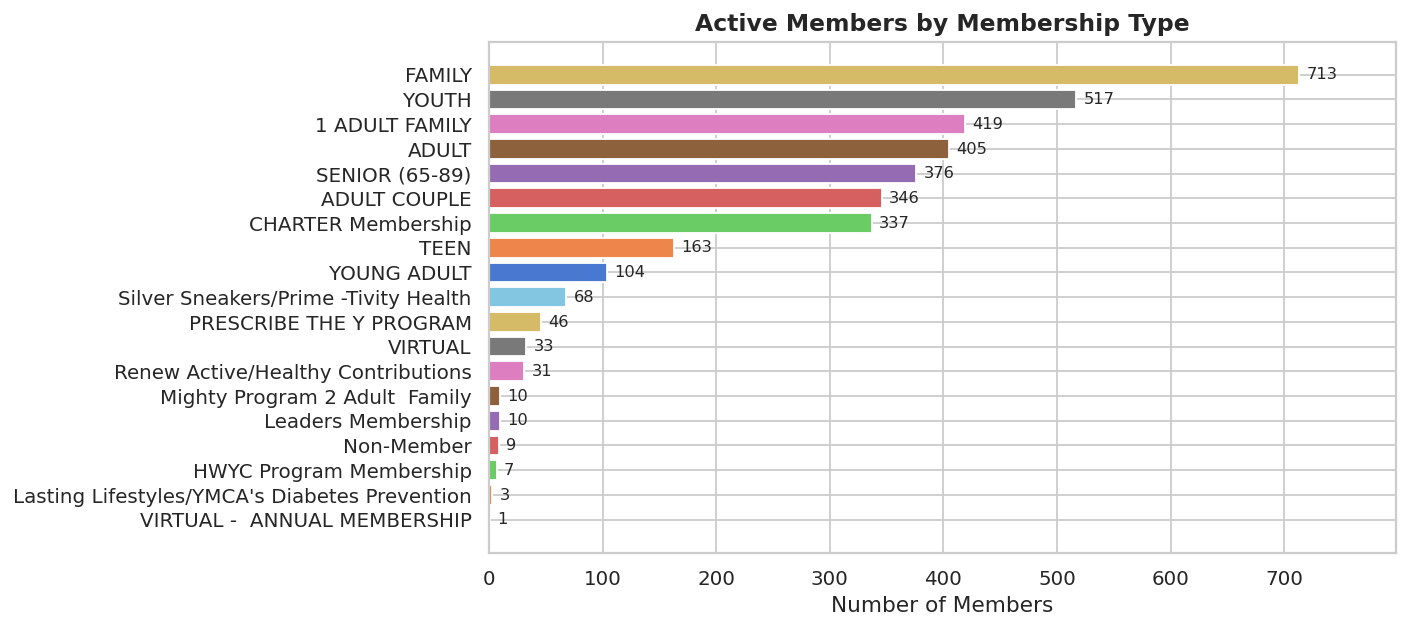

Type
FAMILY                                           713
YOUTH                                            517
1 ADULT FAMILY                                   419
ADULT                                            405
SENIOR (65-89)                                   376
ADULT COUPLE                                     346
CHARTER Membership                               337
TEEN                                             163
YOUNG ADULT                                      104
Silver Sneakers/Prime -Tivity Health              68
PRESCRIBE THE Y PROGRAM                           46
VIRTUAL                                           33
Renew Active/Healthy Contributions                31
Mighty Program 2 Adult  Family                    10
Leaders Membership                                10
Non-Member                                         9
HWYC Program Membership                            7
Lasting Lifestyles/YMCA's Diabetes Prevention      3
VIRTUAL -  ANNUAL MEMBERSHIP             

In [25]:
type_counts = df['Type'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(type_counts.index[::-1], type_counts.values[::-1], color=sns.color_palette('muted', len(type_counts)))
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_xlabel('Number of Members')
ax.set_title('Active Members by Membership Type', fontsize=13, fontweight='bold')
ax.set_xlim(0, type_counts.max() * 1.12)
plt.tight_layout()
plt.show()

print(type_counts.to_string())

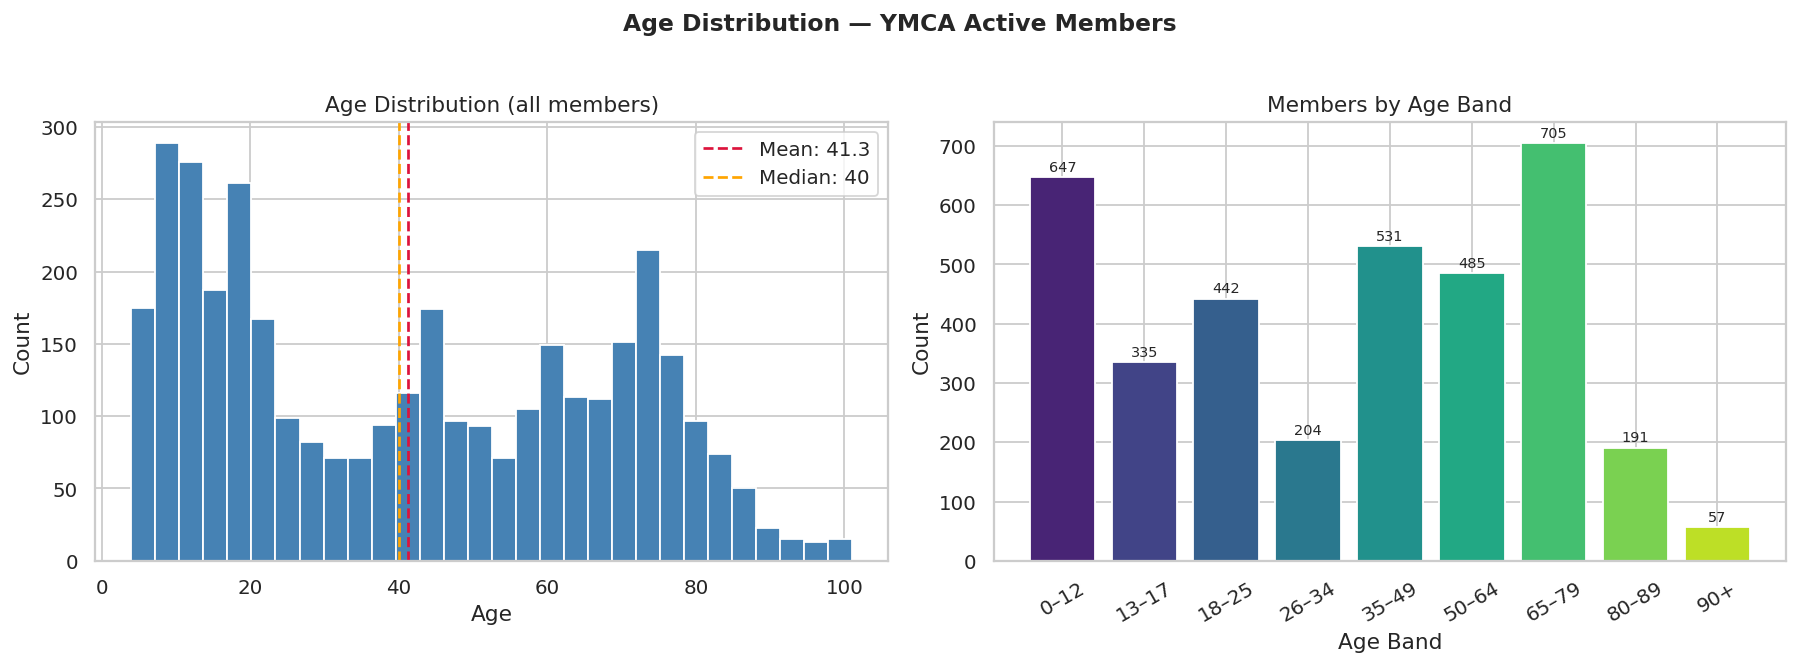

Summary stats:
count    3597.0
mean       41.3
std        26.2
min         4.0
25%        16.0
50%        40.0
75%        66.0
max       101.0
Name: IndividualAge, dtype: float64


In [26]:
ages = df['IndividualAge'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(ages, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(ages.mean(), color='crimson', linestyle='--', label=f'Mean: {ages.mean():.1f}')
axes[0].axvline(ages.median(), color='orange', linestyle='--', label=f'Median: {ages.median():.0f}')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution (all members)')
axes[0].legend()

# Age band bar chart
# Ensure 'AgeBand' column exists before plotting
if 'AgeBand' in df.columns:
    band_counts = df['AgeBand'].value_counts().sort_index()
    axes[1].bar(band_counts.index.astype(str), band_counts.values, color=sns.color_palette('viridis', len(band_counts)))
    axes[1].set_xlabel('Age Band')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Members by Age Band')
    axes[1].tick_params(axis='x', rotation=30)
    for i, v in enumerate(band_counts.values):
        axes[1].text(i, v + 10, str(v), ha='center', fontsize=8)
else:
    axes[1].text(0.5, 0.5, "AgeBand column not found. Please ensure data cleaning cell was run.",
                 horizontalalignment='center', verticalalignment='center',
                 transform=axes[1].transAxes, fontsize=10, color='red')
    axes[1].set_title('Error: AgeBand missing')
    axes[1].set_xticks([])
    axes[1].set_yticks([])


plt.suptitle('Age Distribution — YMCA Active Members', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Summary stats:')
print(ages.describe().round(1))

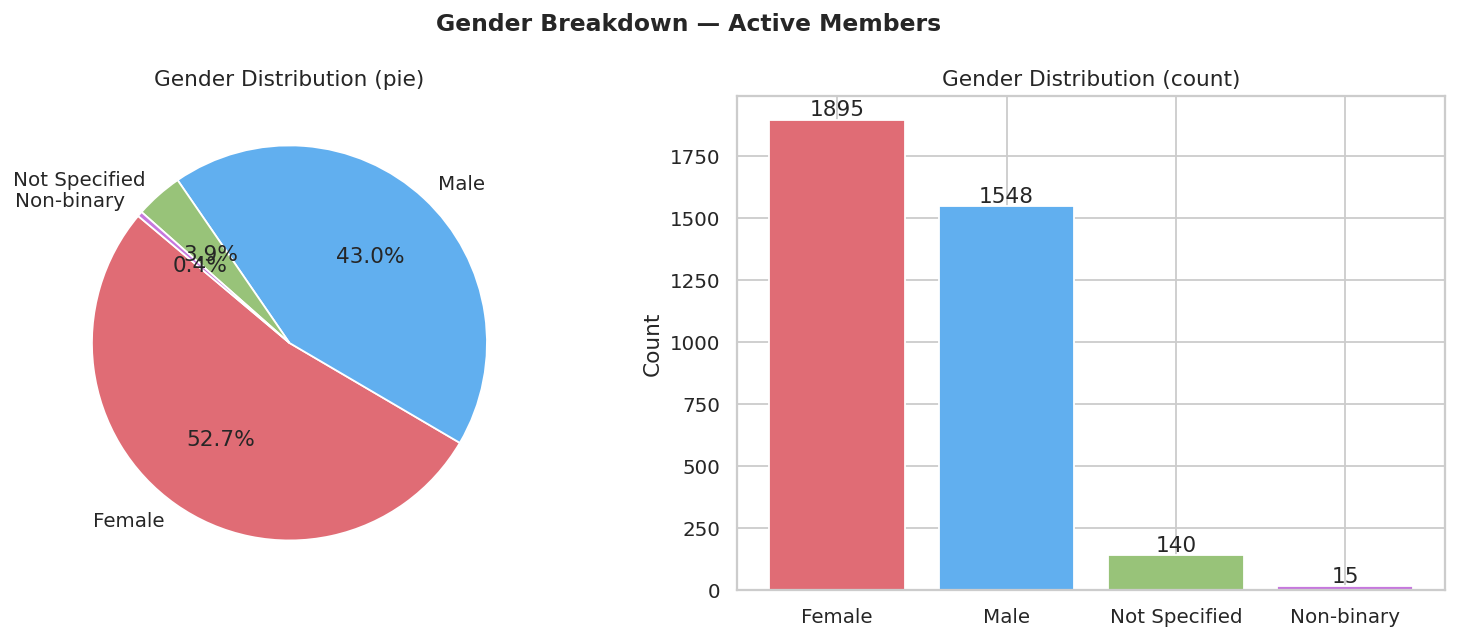

Gender
Female           1895
Male             1548
Not Specified     140
Non-binary         15
Name: count, dtype: int64


In [27]:
gender_counts = df['Gender'].value_counts()
colors = ['#e06c75', '#61afef', '#98c379', '#c678dd']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=colors[:len(gender_counts)], startangle=140)
axes[0].set_title('Gender Distribution (pie)')

# Bar
axes[1].bar(gender_counts.index, gender_counts.values, color=colors[:len(gender_counts)])
axes[1].set_ylabel('Count')
axes[1].set_title('Gender Distribution (count)')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 15, str(v), ha='center')

plt.suptitle('Gender Breakdown — Active Members', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(gender_counts)

Members with a discount: 1,174 / 3,598  (32.6%)


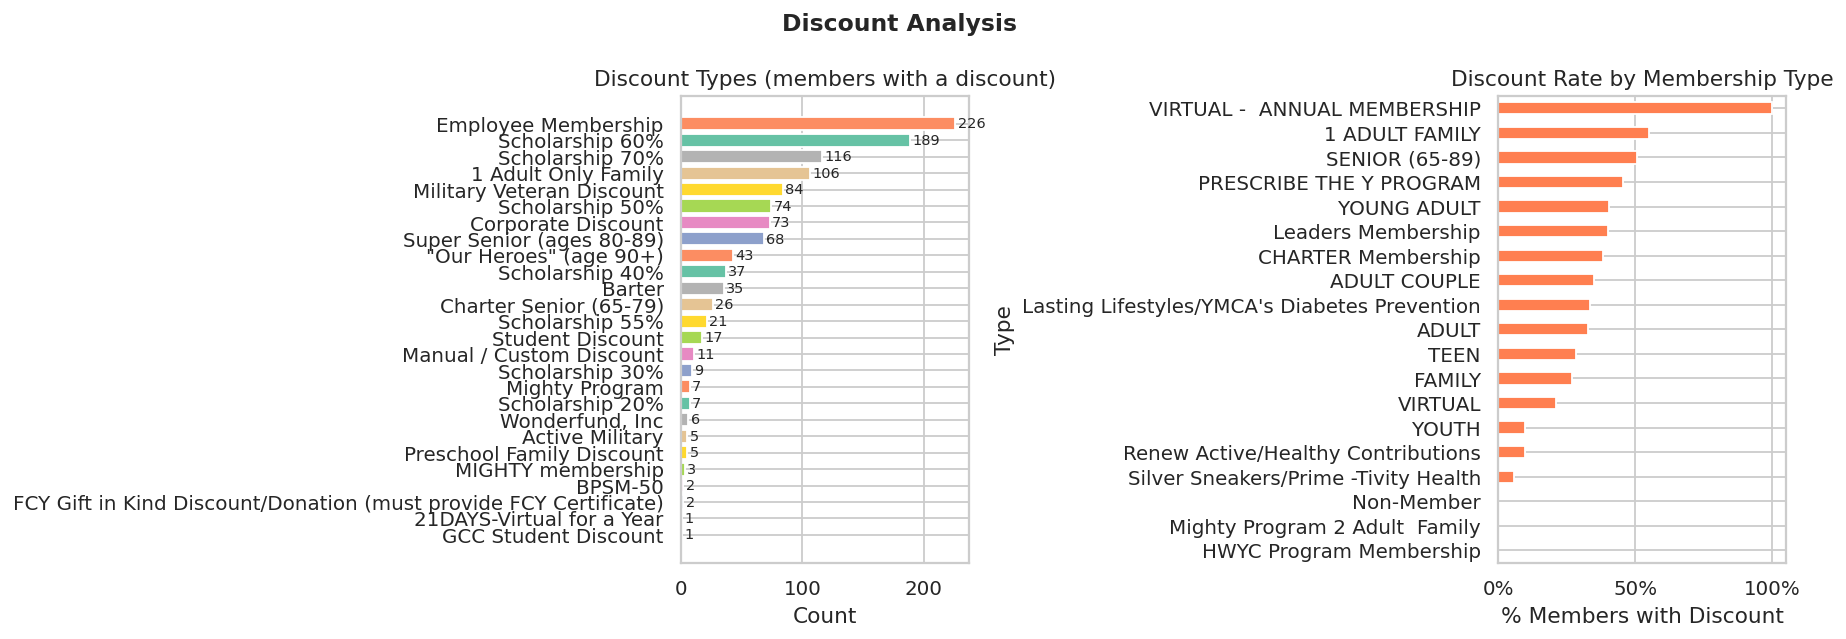

In [28]:
# ── Overall discount rate ──────────────────────────────────────────────────────
disc_rate = df['HasDiscount'].mean() * 100
print(f'Members with a discount: {df["HasDiscount"].sum():,} / {len(df):,}  ({disc_rate:.1f}%)')

# ── Discount type breakdown (exclude 'None') ───────────────────────────────────
disc_counts = df[df['Discount'] != 'None']['Discount'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: discount types
axes[0].barh(disc_counts.index[::-1], disc_counts.values[::-1],
             color=sns.color_palette('Set2', len(disc_counts)))
axes[0].set_xlabel('Count')
axes[0].set_title('Discount Types (members with a discount)')
for i, v in enumerate(disc_counts.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=8)

# Right: % with discount by membership type
disc_by_type = (
    df.groupby('Type')['HasDiscount']
    .mean()
    .sort_values(ascending=True)
    * 100
)
disc_by_type.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('% Members with Discount')
axes[1].set_title('Discount Rate by Membership Type')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle('Discount Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

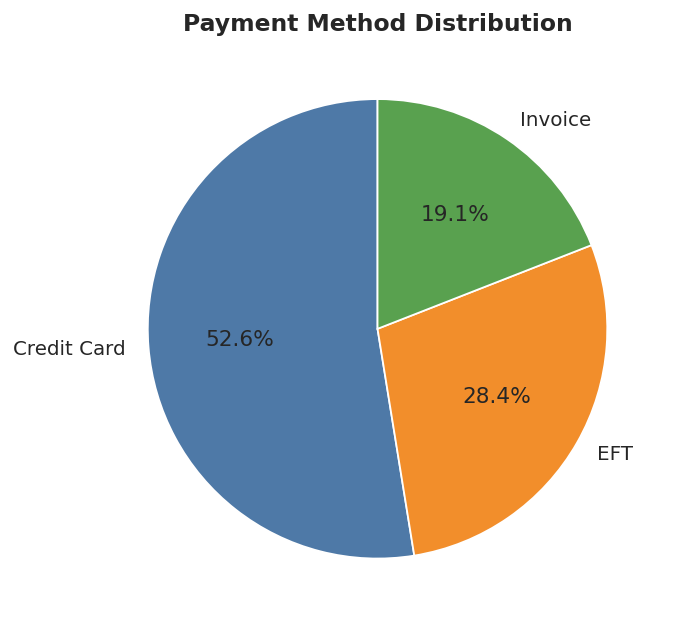

Payment Type
Credit Card    1891
EFT            1021
Invoice         686
Name: count, dtype: int64


In [29]:
pay_counts = df['Payment Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    pay_counts, labels=pay_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#4e79a7', '#f28e2b', '#59a14f']
)
ax.set_title('Payment Method Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(pay_counts)

Total monthly recurring revenue (all households): $111,919.71
  Households paying $0 (fully subsidised): 0
  Households paying >$0: 1842


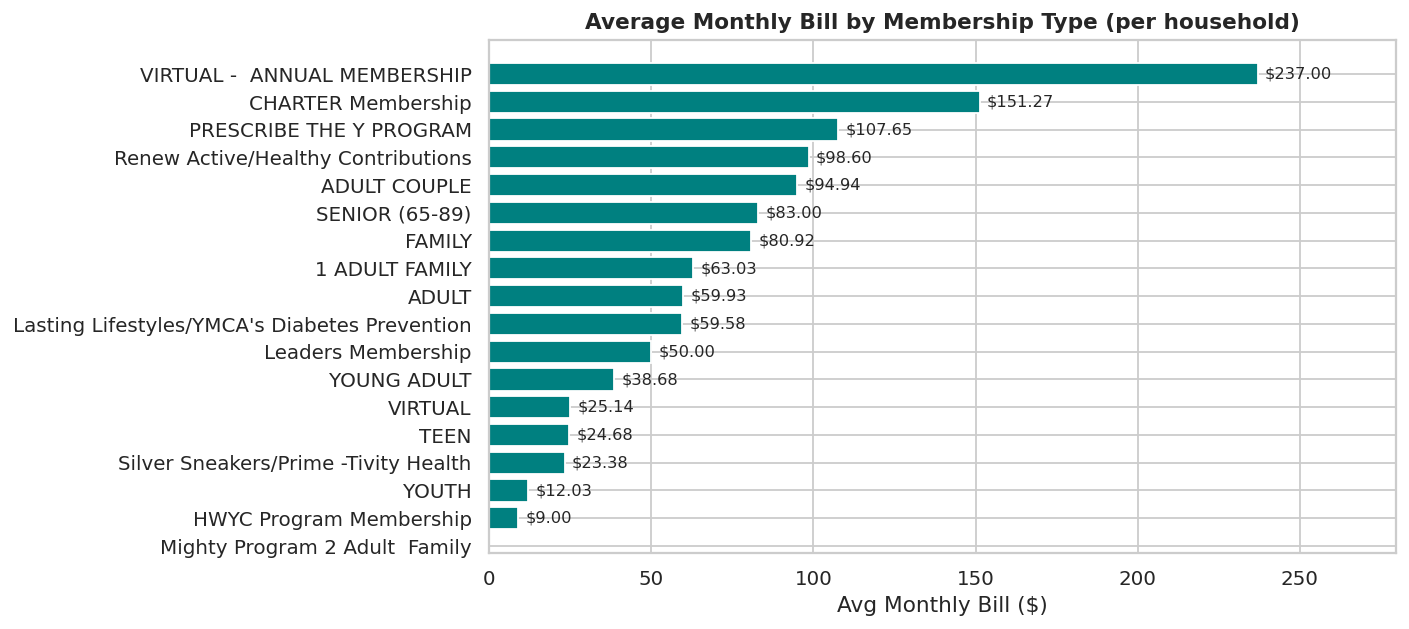

In [30]:
# Per-household billing (de-duplicate by UID so family members aren't counted multiple times)
hh_bill = df.drop_duplicates('UID')[['UID', 'Type', 'MonthlyBill', 'HasDiscount']]

print(f'Total monthly recurring revenue (all households): ${hh_bill["MonthlyBill"].sum():,.2f}')
print(f'  Households paying $0 (fully subsidised): {(hh_bill["MonthlyBill"]==0).sum()}')
print(f'  Households paying >$0: {(hh_bill["MonthlyBill"]>0).sum()}')

# Average bill by membership type
avg_bill = hh_bill.groupby('Type')['MonthlyBill'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(avg_bill.index[::-1], avg_bill.values[::-1], color='teal')
ax.bar_label(bars, fmt='$%.2f', padding=4, fontsize=9)
ax.set_xlabel('Avg Monthly Bill ($)')
ax.set_title('Average Monthly Bill by Membership Type (per household)', fontsize=12, fontweight='bold')
ax.set_xlim(0, avg_bill.max() * 1.18)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5258/4207506001.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='Type', y='IndividualAge', order=order,
/tmp/ipykernel_5258/4207506001.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)


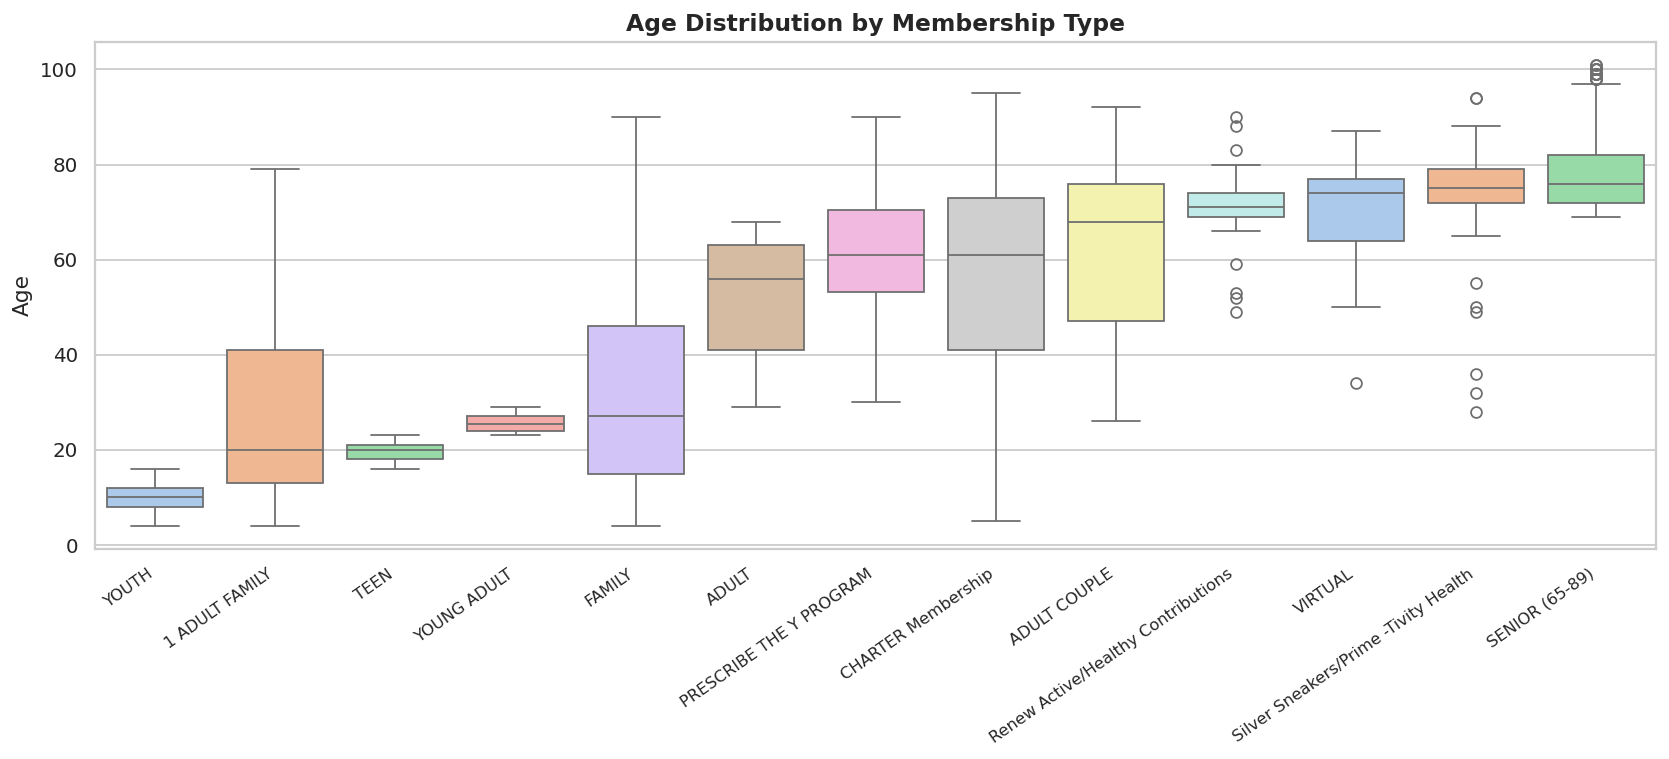

In [31]:
# Limit to types with enough members for a meaningful box plot (>= 30)
common_types = df['Type'].value_counts()[df['Type'].value_counts() >= 30].index
subset = df[df['Type'].isin(common_types)]

# Sort types by median age
order = subset.groupby('Type')['IndividualAge'].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=subset, x='Type', y='IndividualAge', order=order,
            palette='pastel', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
ax.set_xlabel('')
ax.set_ylabel('Age')
ax.set_title('Age Distribution by Membership Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

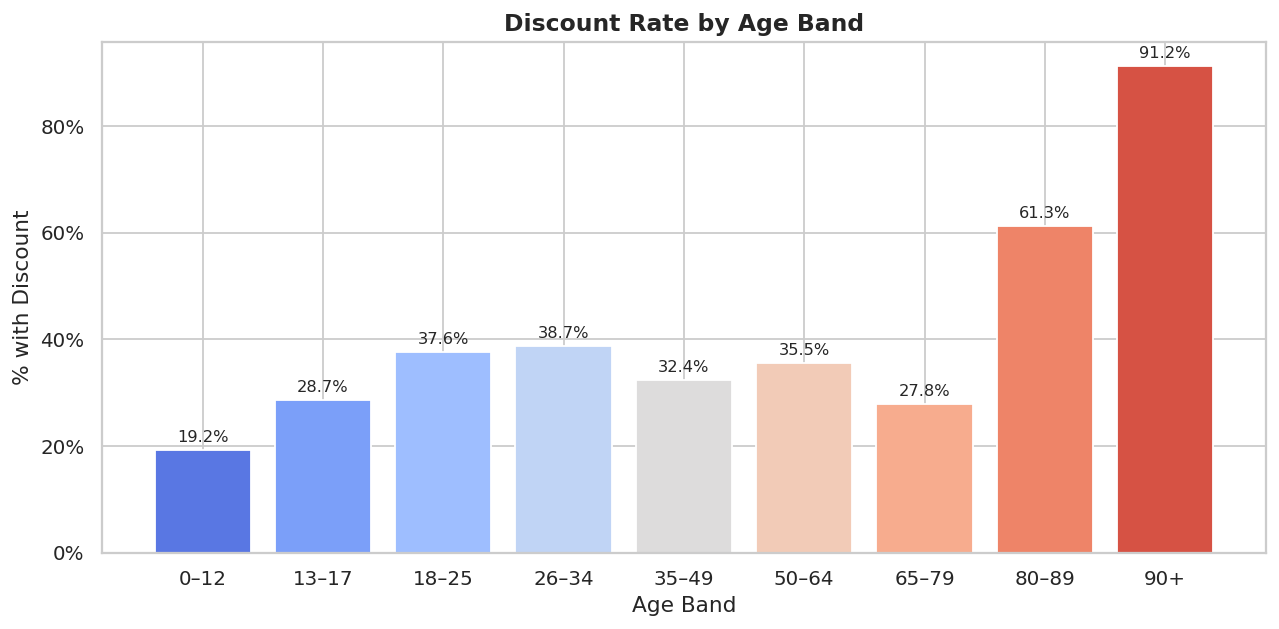

           N  DiscountPct
AgeBand                  
0–12     647         19.2
13–17    335         28.7
18–25    442         37.6
26–34    204         38.7
35–49    531         32.4
50–64    485         35.5
65–79    705         27.8
80–89    191         61.3
90+       57         91.2


In [32]:
disc_age = (
    df.groupby('AgeBand', observed=True)['HasDiscount']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'DiscountRate', 'count': 'N'})
)
disc_age['DiscountPct'] = disc_age['DiscountRate'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(disc_age.index.astype(str), disc_age['DiscountPct'],
              color=sns.color_palette('coolwarm', len(disc_age)))
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('Age Band')
ax.set_ylabel('% with Discount')
ax.set_title('Discount Rate by Age Band', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

print(disc_age[['N', 'DiscountPct']].round(1))

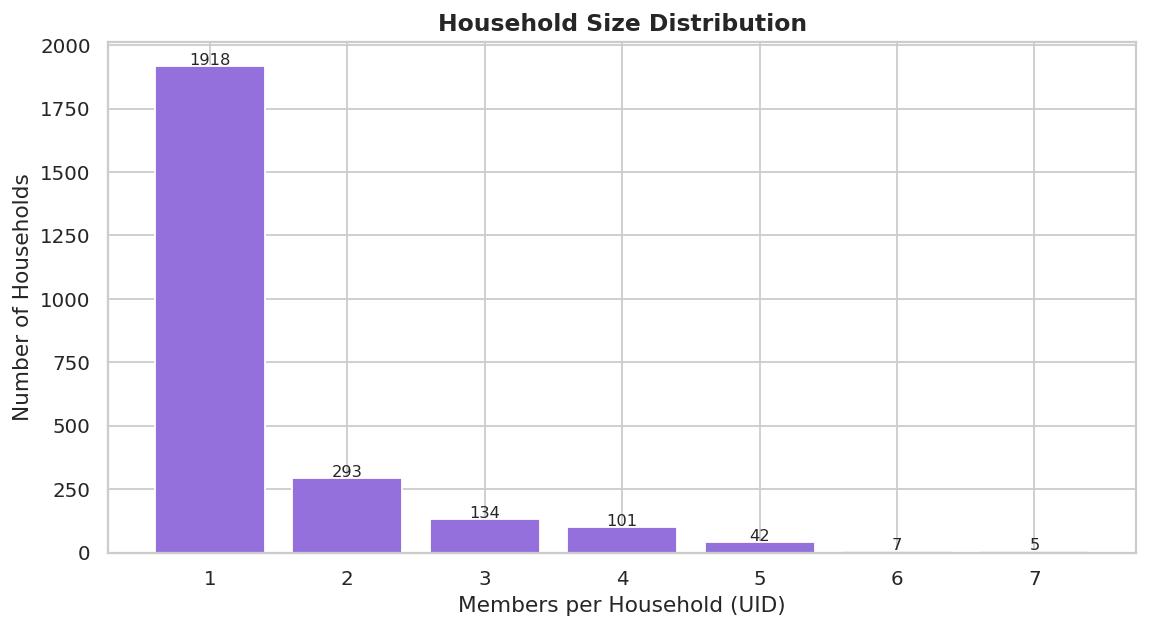

1    1918
2     293
3     134
4     101
5      42
6       7
7       5
Name: count, dtype: int64


In [33]:
hh_size = df.groupby('UID').size().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(hh_size.index.astype(str), hh_size.values, color='mediumpurple')
ax.set_xlabel('Members per Household (UID)')
ax.set_ylabel('Number of Households')
ax.set_title('Household Size Distribution', fontsize=13, fontweight='bold')
for i, v in enumerate(hh_size.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(hh_size)

In [34]:
summary = (
    df.groupby('Type')
    .agg(
        Members       = ('MID', 'count'),
        Avg_Age       = ('IndividualAge', 'mean'),
        Pct_Discount  = ('HasDiscount', 'mean'),
        Avg_Bill      = ('MonthlyBill', 'mean'),
        Female_Pct    = ('Gender', lambda x: (x == 'Female').mean()),
        Male_Pct      = ('Gender', lambda x: (x == 'Male').mean()),
    )
    .sort_values('Members', ascending=False)
)

summary['Avg_Age']      = summary['Avg_Age'].round(1)
summary['Pct_Discount'] = (summary['Pct_Discount'] * 100).round(1).astype(str) + '%'
summary['Avg_Bill']     = summary['Avg_Bill'].round(2).apply(lambda x: f'${x:,.2f}')
summary['Female_Pct']   = (summary['Female_Pct'] * 100).round(1).astype(str) + '%'
summary['Male_Pct']     = (summary['Male_Pct'] * 100).round(1).astype(str) + '%'

summary

,Members,Avg_Age,Pct_Discount,Avg_Bill,Female_Pct,Male_Pct
Type,,,,,,
FAMILY,713,31.1,26.9%,$82.95,49.1%,45.2%
YOUTH,517,10.1,9.9%,$12.06,53.0%,41.6%
1 ADULT FAMILY,419,26.6,54.9%,$65.16,56.1%,40.3%
ADULT,404,52.1,32.6%,$59.78,56.3%,37.8%
SENIOR (65-89),376,78.4,50.5%,$83.00,67.3%,31.4%
ADULT COUPLE,346,62.6,35.0%,$95.82,52.9%,41.9%
CHARTER Membership,337,54.6,38.3%,$149.85,45.7%,54.0%
TEEN,163,19.7,28.2%,$24.62,29.4%,66.3%
YOUNG ADULT,104,25.5,40.4%,$38.81,45.2%,50.0%
